# Project 1 Widgets

This notebook contains some 'widgets' - in other words, code snippets - that demonstrate how to create graphs and analyze data for Project 1. You are welcome to take the code from these widgets and modify it for your own project. Note: Some of the things that apply to my data set may not apply to yours.

**You will need to run the Widgets in order so that all the preceding data and libraries have been loaded.**

## Widget 1

Import libraries, load data into pandas dataframe, clean column names, etc.

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt
from matplotlib.ticker import MaxNLocator
from scipy import stats
import meteostat as ms

file = 'data.csv'

# Load data into pandas dataframe
df = pd.read_csv(file)

# Rename columns
df.columns = ['Time', 'Temp (deg C)', 'Pressure (mbar)', 'Humidity (%)', 'Altitude (m)']

# Drop altitude - we don't need it for this project
df.drop(columns=['Altitude (m)'], inplace=True)

# Get ride of decimal part of time and the seconds - this level of detail is not needed
df['Time'] = df['Time'].str.split(".").str.get(0)
df['Time'] = df['Time'].str[0:16]

# Choose start and end indices (in case you want to discard some of the data at the start/end)
# Your should analyse and report on 2-5 days of continuous hourly data
start_id = 1485 + 120
end_id = start_id+277


# Copy the dataframe into a new dataframe called 'bme280' with the slice you are going to work with
bme280 = df[start_id:end_id].copy()
bme280.reset_index(drop=True, inplace=True)

# Convert the 'Time' strings to dateime objects - if we do this consistently, it will be easily to plot and analyze our data
bme280['Time'] = pd.to_datetime(bme280['Time'])

# Check contents of dataframe
bme280

,Time,Temp (deg C),Pressure (mbar),Humidity (%)
0,2026-03-08 15:00:00,18.021484,830.129048,39.479690
1,2026-03-08 16:00:00,19.411914,829.480716,37.172562
2,2026-03-08 17:00:00,19.682813,828.940569,36.455591
3,2026-03-08 18:00:00,21.183594,828.802180,35.380109
4,2026-03-08 19:00:00,18.869727,829.220547,34.599388
...,...,...,...,...
272,2026-03-19 23:00:00,19.903711,840.823500,33.026274
273,2026-03-20 00:00:00,19.045508,840.979521,33.627158
274,2026-03-20 01:00:00,18.006445,841.023588,34.824495
275,2026-03-20 02:00:00,16.596094,841.235249,38.125377


## Widget 2

Generate summary statistics for sensor readings for the time period measured.

`bme280.describe()` gives you everything you need, including 5-number summary.

In [27]:
# Summary stats for sensor readings
bme280.describe()

,Time,Temp (deg C),Pressure (mbar),Humidity (%)
count,277,277.000000,277.000000,277.000000
mean,2026-03-14 09:00:00,13.420508,834.588381,42.674996
min,2026-03-08 15:00:00,-3.933984,821.192570,21.557529
25%,2026-03-11 12:00:00,8.586133,830.177574,32.858384
50%,2026-03-14 09:00:00,14.157031,834.051939,39.118941
75%,2026-03-17 06:00:00,18.794531,839.488937,52.348786
max,2026-03-20 03:00:00,30.028125,844.482677,72.975837
std,NaN,7.363715,5.610324,13.370283


## Widget 3

Plot line graph showing one of the sensor readings over time. Remember you will need to do this for each quantity (temp, pressure, humidity) and provide a commentary.

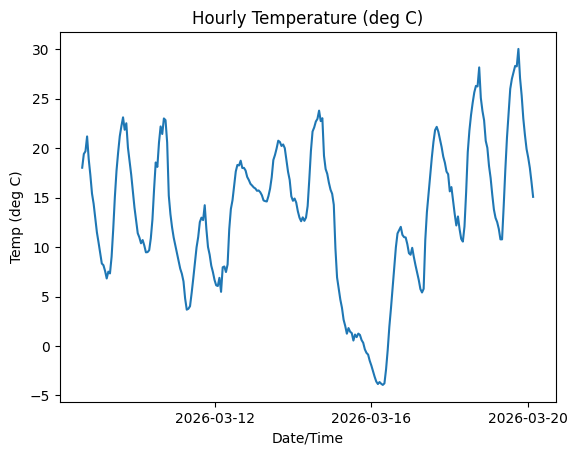

In [28]:
# Set up figure and axes using matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.plot(bme280['Time'], bme280['Temp (deg C)'])

# Set the maximum number of major ticks to 3 - adjust this number so that x axis labels don't overlap
ax.xaxis.set_major_locator(MaxNLocator(4))

# Set up title and axis labels and plot graph
plt.title("Hourly Temperature (deg C)")
plt.ylabel("Temp (deg C)")
plt.xlabel("Date/Time")
plt.show()

## Widget 4

Get comparable data from meteostat and store in a `pandas` dataframe.

Note: We will use Denver International Airport (DIA) weather data as this is the most up to date. The station code is 72565.

In [29]:
# Pick a station for meteostat data and check what is available
station = '72565'  # This is the DIA station. You can try other Denver stations, but DIA has the most recent data

inventory = ms.stations.inventory(station)

# This just prints what data is available and for what time periods from the station.
# If time period goes into the future, it includes a forecast.
print(f"Data available from {inventory.start} to {inventory.end}.")
print(f"Available parameters: {inventory.parameters}")

Data available from 1994-07-18 to 2026-03-17.
Available parameters: [<Parameter.PRCP: 'prcp'>, <Parameter.PRES: 'pres'>, <Parameter.TEMP: 'temp'>, <Parameter.TMAX: 'tmax'>, <Parameter.TMIN: 'tmin'>, <Parameter.TXMN: 'txmn'>, <Parameter.TXMX: 'txmx'>, <Parameter.CLDC: 'cldc'>, <Parameter.COCO: 'coco'>, <Parameter.RHUM: 'rhum'>, <Parameter.WDIR: 'wdir'>, <Parameter.WSPD: 'wspd'>, <Parameter.SNWD: 'snwd'>, <Parameter.TSUN: 'tsun'>, <Parameter.WPGT: 'wpgt'>]


In [30]:
# Set start and end dates to be start and end of your hourly sensor readings
start= bme280.loc[0, 'Time']
end = bme280.loc[len(bme280)-1, 'Time']

# Select Station - Use Denver International Airport as other stations may not have recent hourly data yet
DIA_stn = ms.Station(id=station)

#Get data
DIA_data = ms.hourly(DIA_stn, start, end)

# Store data in pandas dataframes
dia = DIA_data.fetch()
dia = dia.reset_index()

# Change datetime strings to datetime objects
dia['time'] = pd.to_datetime(dia['time'])

# Rename columns to be consistent with our bme280 dataframe
dia.rename(columns={'time':'Time', 'temp':'Temp (deg C)', 'rhum':'Humidity (%)', 'pres':'Pressure (mbar)'}, inplace=True)
dia

,Time,Temp (deg C),Humidity (%),prcp,snwd,wdir,wspd,wpgt,Pressure (mbar),tsun,cldc,coco
0,2026-03-08 15:00:00,7.0,41,<NA>,<NA>,200,22.0,<NA>,1014.0,<NA>,2,2
1,2026-03-08 16:00:00,8.0,42,<NA>,<NA>,200,19.0,<NA>,1014.0,<NA>,2,2
2,2026-03-08 17:00:00,11.0,35,<NA>,<NA>,210,19.0,<NA>,1013.0,<NA>,2,2
3,2026-03-08 18:00:00,13.0,33,<NA>,<NA>,180,13.0,<NA>,1012.0,<NA>,2,2
4,2026-03-08 19:00:00,15.0,27,<NA>,<NA>,0,0.0,<NA>,1011.0,<NA>,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
272,2026-03-19 23:00:00,21.0,16,<NA>,<NA>,218,22.2,<NA>,1008.3,<NA>,5,<NA>
273,2026-03-20 00:00:00,19.5,17,<NA>,<NA>,216,22.2,<NA>,1008.3,<NA>,4,<NA>
274,2026-03-20 01:00:00,17.2,21,<NA>,<NA>,189,20.4,<NA>,1008.9,<NA>,4,<NA>
275,2026-03-20 02:00:00,14.9,26,<NA>,<NA>,184,20.4,<NA>,1009.4,<NA>,4,<NA>


## Widget 5

Plot your sensor readings against the DIA data. You will need to do this for each sensor measurement (temp, pressure, humidity).

In [32]:
# Before plotting, it is good to check you have aligned the datetime values
start_row = 0
end_row = len(bme280)-1
print(bme280.loc[start_row, 'Time'], dia.loc[start_row, 'Time'])
print(bme280.loc[end_row, 'Time'], dia.loc[end_row, 'Time'])

2026-03-08 15:00:00 2026-03-08 15:00:00
2026-03-20 03:00:00 2026-03-20 03:00:00


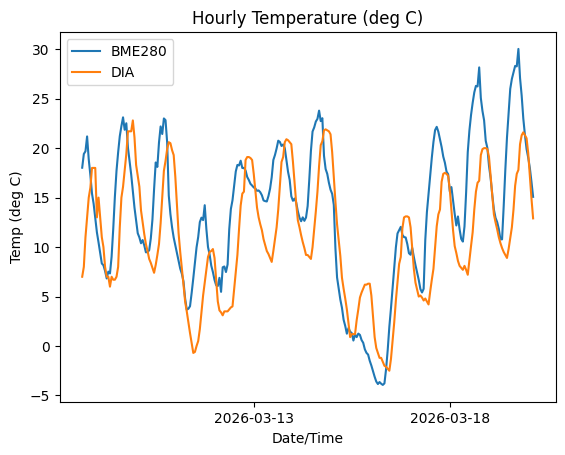

In [33]:
# Set up figure and axes using matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.plot(bme280['Time'], bme280['Temp (deg C)'], label='BME280')
ax.plot(dia['Time'], dia['Temp (deg C)'], label='DIA')
ax.legend()

# Set the maximum number of major ticks to 3 - adjust this number so that x axis labels don't overlap
ax.xaxis.set_major_locator(MaxNLocator(3))

# Set up title and axis labels and plot graph
plt.title("Hourly Temperature (deg C)")
plt.ylabel("Temp (deg C)")
plt.xlabel("Date/Time")
plt.show()

## Widget 6

Side-by-side Box plots. You will need to do this for each sensor reading (temp, pressure, humidity).

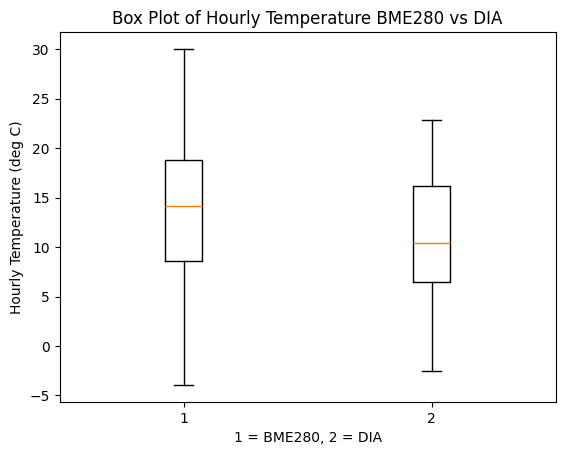

In [34]:
# Create a combined plot for temperature for bme280 sensor and DIA
fig, ax = plt.subplots()

ax.boxplot([bme280['Temp (deg C)'], dia['Temp (deg C)']])
plt.xlabel("1 = BME280, 2 = DIA")
plt.ylabel("Hourly Temperature (deg C)")
plt.title("Box Plot of Hourly Temperature BME280 vs DIA")
plt.show()

## Widget 7

Scatter plot and correlation. We will plot BME280 temperature readings versus DIA readings. You will need to do this for each sensor measurement (temperature, pressure, humidity).

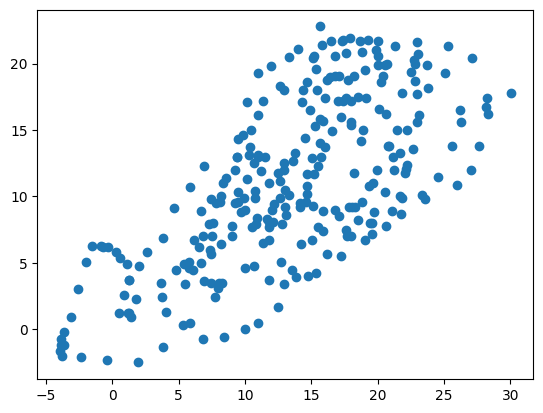

In [35]:
x = bme280['Temp (deg C)']
y = dia['Temp (deg C)']
plt.scatter(x, y)
plt.show()

In [36]:
from scipy import stats

slope, intercept, r, p, std_err = stats.linregress(x, y)
print(f"slope: {slope:.3f}")
print(f"intercept: {intercept:.3f}")
print(f"r: {r:.3f}")

slope: 0.587
intercept: 3.117
r: 0.689


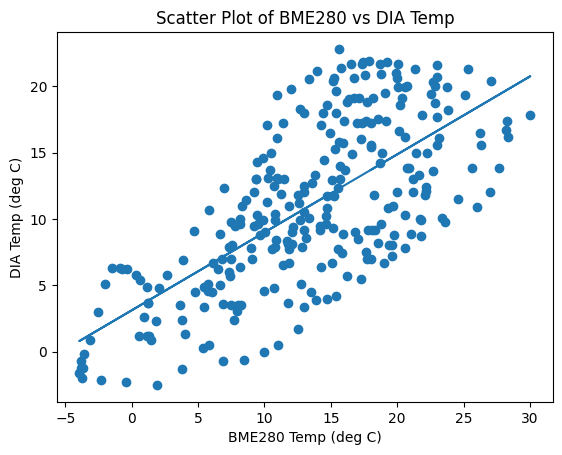

In [37]:
def predict(x):
  return slope * x + intercept
    
model_data = list(map(predict, x))
plt.plot(x, model_data)
plt.scatter(x, y)
plt.xlabel("BME280 Temp (deg C)")
plt.ylabel("DIA Temp (deg C)")
plt.title("Scatter Plot of BME280 vs DIA Temp")
plt.show()

## Widget 8

This Widget performs a hypothesis test to determine whether there is a statistically significant linear relationship between two quantities, based on the samples provided. In this case, we seek to establish whether there is a linear relationship between temperature as measured by the bme280 versus that measured at DIA.

In [38]:
from scipy.stats import pearsonr

# We are testing two competing hypotheses
# H0: No linear correlation between the two quantities
# H1: Statistically significant correlation between the two quantities

# Sample data for correlation test
t1 = bme280['Temp (deg C)']
t2 = dia['Temp (deg C)']

# Perform the Pearson correlation test
correlation_coefficient, p_value = pearsonr(t1, t2)

# Define significance level (alpha) 
# 0.05 is typically used, which corresponds to a 95% confidence level.
alpha = 0.05

# Print the results
print(f"Pearson Correlation Coefficient (r): {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis (H0). There is a statistically significant linear relationship between the two quantities.)")
else:
    print("\nConclusion: Do not reject the null hypothesis (H0). There is not enough evidence to suggest a significant linear relationship.)")


Pearson Correlation Coefficient (r): 0.6890
P-value: 0.0000

Conclusion: Reject the null hypothesis (H0). There is a statistically significant linear relationship between the two quantities.)


## Widget 9

This widget performs a [paired t-test](https://en.wikipedia.org/wiki/Student%27s_t-test) (for non-independent samples) to see if there is a statistically significant difference between the mean temperature for data collected by the sensor and the mean for data from Meteostat. The **p-value** is a measure of the statistical significance. A p-value less than 0.05 indicates there is a statistically significant difference at the 95% confidence level.

In [13]:
from scipy import stats

t1 = bme280['Temp (deg C)']
t2 = dia['Temp (deg C)']

# Perform paired samples t-test
t_statistic_rel, p_value_rel = stats.ttest_rel(t1, t2)


print(f"\nPaired Samples T-test Results:")
print(f"T-statistic: {t_statistic_rel:.4f}")
print(f"P-value: {p_value_rel:.4f}\n")
if p_value_rel < 0.05:
    print(f"Since {p_value_rel:.4f} < 0.05, the difference between the means is statistically significant at the 95% confidence level.")
else:
    print(f"Since {p_value_rel:.4f} >= 0.05, the difference between the means is NOT statistically significant at the 95% confidence level.")


Paired Samples T-test Results:
T-statistic: 4.9035
P-value: 0.0000

Since 0.0000 < 0.05, the difference between the means is statistically significant at the 95% confidence level.
